In [62]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER, GREEN = '#4878CF', '#E84D0E', '#888888', '#F0A500', '#4dac26'

In [63]:
# =============================================================================
# PARAMETERS -- edit this cell to explore how results change
# =============================================================================

# --- Seeds ---
VENDOR_SEED    = 1     # integer >= 0; different seeds simulate consulting a different vendor
PORTFOLIO_SEED = 42    # keep fixed to compare vendors on the same loan book

# --- Probability framing ---
# Two framings:
#
#  CONDITIONAL -- the 1-in-200 year flood is treated as certain (p = 1).
#                 Uses the full d_200yr damage ratio.  Isolates vendor disagreement.
#
#  AAL          -- converts 200yr RP damage to expected annual damage:
#                      d_eff = d_200yr * AAL_FACTOR
#                  More natural for ongoing capital planning or provisioning.
#
# AAL_FACTOR guidance:
#   1/200 = 0.005  -- flat hazard curve / simplest assumption
#   Values above 0.005 reflect heavier-tailed exceedance curves.

FRAMING    = 'aal'  # 'conditional'  or  'aal'
AAL_FACTOR = 0.25           # scales d_200yr -> effective annual damage

# --- Damage pass-through ---
# THETA controls what fraction of physical damage reduces collateral market value.
# THETA = 1.0: full pass-through (£1 damage -> £1 collateral reduction)
# THETA < 1.0: partial (insurance, resilience, flood barriers etc.)
THETA = 0.5

# --- Basel III SA underwriting thresholds ---
LTV_BAR_1 = 0.60   # approve at standard terms if stressed LTV <= this
LTV_BAR_2 = 0.80   # conditional approval if stressed LTV <= this; reject above

# --- Risk weights by LTV band ---
RW_STANDARD    = 0.70   # LTV <= LTV_BAR_1
RW_CONDITIONAL = 0.90   # LTV_BAR_1 < LTV <= LTV_BAR_2
RW_REJECT      = 1.1   # LTV > LTV_BAR_2

CAPITAL_RATIO = 0.08    # Basel III minimum (Tier 1 + Tier 2)

# --- Loan portfolio ---
# Each loan: V0 = property value, LTV0 = origination LTV, Loan = LTV0 * V0
V0_LN_MU    = -0.2   # log-mean of property value (median ~GBP 0.8m)
V0_LN_SIGMA =  0.5   # log-std
LTV0_LOW    =  0.55  # origination LTV lower bound
LTV0_HIGH   =  0.8  # origination LTV upper bound

# --- Vendor uncertainty sweep ---
N_VENDOR_DRAWS = 1000   # number of vendor draws for the uncertainty analysis

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [64]:
# =============================================================================
# DATA, PORTFOLIO, AND TRANSMISSION
# Run this cell after editing parameters above.
# =============================================================================

df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters for each property (mode from mean constraint)
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b)."""
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u,       0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u,   0) * span * np.maximum(b - c, 0))
    x = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

# ── Sample one vendor draw ────────────────────────────────────────────────────
vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)

# ── Loan portfolio ────────────────────────────────────────────────────────────
port_rng = np.random.default_rng(PORTFOLIO_SEED)
v0 = stats.lognorm.rvs(
    s=V0_LN_SIGMA, scale=np.exp(V0_LN_MU), size=n,
    random_state=int(port_rng.integers(2**31))
)
ltv_0 = port_rng.uniform(LTV0_LOW, LTV0_HIGH, size=n)
loan  = ltv_0 * v0   # outstanding balance = LTV0 * property value

# ── Transmission functions ────────────────────────────────────────────────────
def eff_damage(d):
    """Apply framing: return effective damage ratio used in transmission."""
    return d if FRAMING == 'conditional' else d * AAL_FACTOR

def transmit(d, theta=THETA, bar1=LTV_BAR_1, bar2=LTV_BAR_2):
    """Damage ratio -> impaired collateral -> stressed LTV -> outcome bucket -> RWA."""
    d_e   = eff_damage(d)
    v_imp = np.maximum(v0 * (1.0 - theta * d_e), v0 * 1e-6)
    ltv_s = loan / v_imp
    out   = np.where(ltv_s <= bar1, 0, np.where(ltv_s <= bar2, 1, 2))
    rw    = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[out]
    rwa   = loan * rw
    cap   = CAPITAL_RATIO * rwa
    return ltv_s, out, rwa, cap

# ── Apply to single vendor draw ───────────────────────────────────────────────
ltv_stressed, outcome, rwa, capital = transmit(d_vendor)

# ── Baseline (no damage) ──────────────────────────────────────────────────────
ltv_base    = ltv_0
outcome_base = np.where(ltv_base <= LTV_BAR_1, 0,
               np.where(ltv_base <= LTV_BAR_2, 1, 2))
rw_base     = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[outcome_base]
rwa_base    = loan * rw_base
capital_base = CAPITAL_RATIO * rwa_base

# ── Point-estimate outcomes at d_min / d_mean / d_max ────────────────────────
_, out_min,  rwa_min,  _  = transmit(tri_a)
_, out_mean, rwa_mean, _  = transmit(df['mean_dr'].values)
_, out_max,  rwa_max,  _  = transmit(tri_b)

# ── Sort index by mean damage ─────────────────────────────────────────────────
idx   = np.argsort(df['mean_dr'].values)
x_pos = np.arange(n)

# ── Summary ───────────────────────────────────────────────────────────────────
framing_label = 'Conditional (p=1)' if FRAMING == 'conditional' else f'AAL (×{AAL_FACTOR})'
out_names = ['Standard', 'Conditional', 'Reject']
counts = [(outcome == k).sum() for k in range(3)]
print(f"Framing: {framing_label}  |  theta={THETA}  |  Vendor seed={VENDOR_SEED}")
print(f"\nBaseline (no damage):")
print(f"  {'  '.join(f'{out_names[k]}: {(outcome_base==k).sum():2d}' for k in range(3))}")
print(f"  Portfolio RWA: GBP{rwa_base.sum():.3f}m   Capital: GBP{capital_base.sum():.4f}m")
print(f"\nSingle vendor draw:")
print(f"  {'  '.join(f'{out_names[k]}: {counts[k]:2d}' for k in range(3))}")
print(f"  Portfolio RWA: GBP{rwa.sum():.3f}m   Capital: GBP{capital.sum():.4f}m")
print(f"  RWA uplift vs baseline: {(rwa.sum()/rwa_base.sum() - 1)*100:+.1f}%")

Framing: AAL (×0.25)  |  theta=0.5  |  Vendor seed=1

Baseline (no damage):
  Standard: 22  Conditional: 78  Reject:  0
  Portfolio RWA: GBP52.195m   Capital: GBP4.1756m

Single vendor draw:
  Standard: 14  Conditional: 81  Reject:  5
  Portfolio RWA: GBP54.053m   Capital: GBP4.3242m
  RWA uplift vs baseline: +3.6%


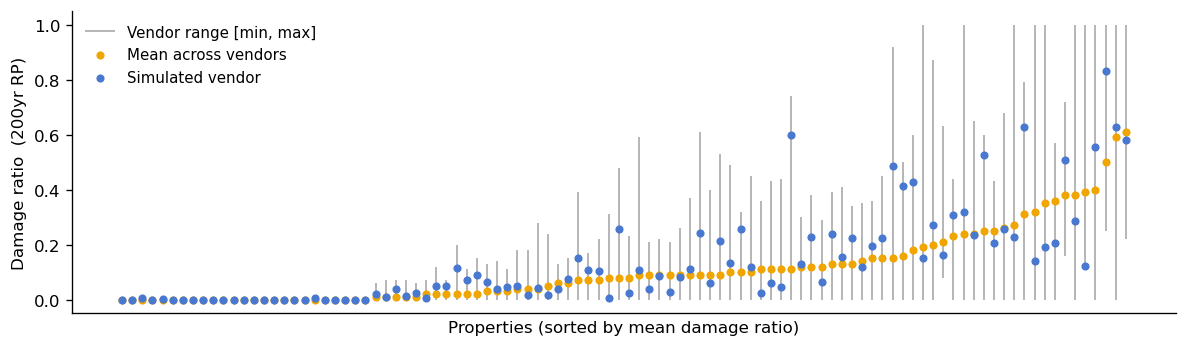

In [65]:
# Vendor spread by property (sorted by mean damage ratio)
fig, ax = plt.subplots(figsize=(10, 3))
ax.vlines(x_pos, tri_a[idx], tri_b[idx], color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, df['mean_dr'].values[idx], color=AMBER, s=15, zorder=3,
           label='Mean across vendors')
ax.scatter(x_pos, d_vendor[idx], color=BLUE, s=15, zorder=3, label='Simulated vendor')
ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio  (200yr RP)')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

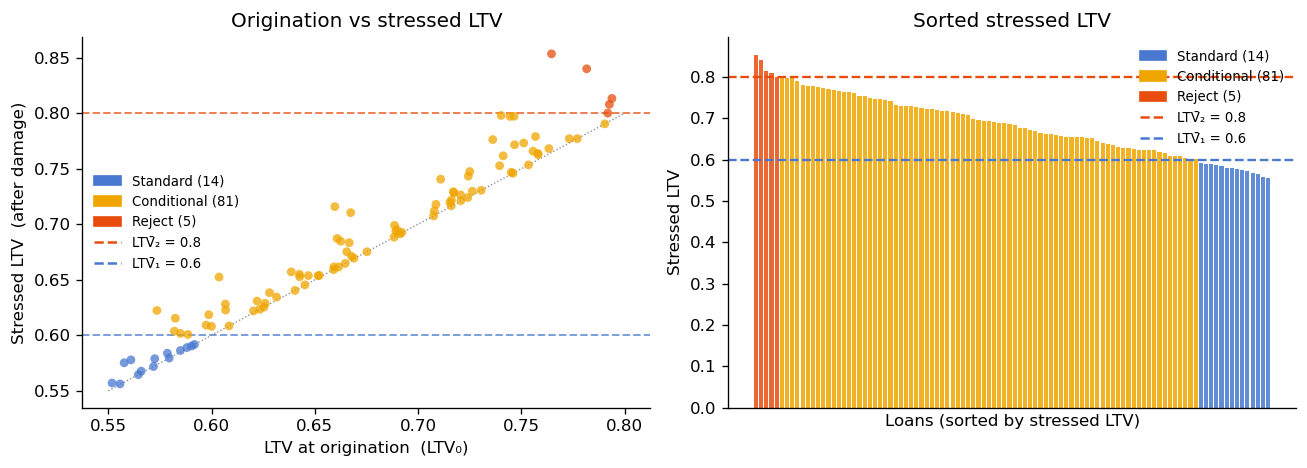

In [66]:
# Stressed LTV scatter and outcome breakdown
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: LTV_0 vs LTV_stressed, coloured by outcome ────────────────────────
ax = axes[0]
colours_loan = [BLUE if o == 0 else (AMBER if o == 1 else RED) for o in outcome]
ax.scatter(ltv_0, ltv_stressed, c=colours_loan, s=28, alpha=0.75, edgecolors='none', zorder=3)
ax.axhline(LTV_BAR_1, color=BLUE,  lw=1.2, ls='--', alpha=0.7,
           label=f'LTV̄₁ = {LTV_BAR_1}  (standard/conditional)')
ax.axhline(LTV_BAR_2, color=RED,   lw=1.2, ls='--', alpha=0.7,
           label=f'LTV̄₂ = {LTV_BAR_2}  (conditional/reject)')
ax.plot([LTV0_LOW, LTV0_HIGH], [LTV0_LOW, LTV0_HIGH], color=GREY, lw=0.8, ls=':',
        label='No damage (LTV_s = LTV_0)')
n0, n1, n2 = [(outcome == k).sum() for k in range(3)]
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label=f'Standard ({n0})'),
    mpatches.Patch(color=AMBER, label=f'Conditional ({n1})'),
    mpatches.Patch(color=RED,   label=f'Reject ({n2})'),
    # plt.Line2D([0],[0], color=GREY, ls='--', label=f'LTV̄₁={LTV_BAR_1} / LTV̄₂={LTV_BAR_2}'),
    plt.Line2D([0],[0], color=RED,  ls='--', label=f'LTV̄₂ = {LTV_BAR_2}'),
    plt.Line2D([0],[0], color=BLUE, ls='--', label=f'LTV̄₁ = {LTV_BAR_1}'),
], frameon=False, fontsize=8)
ax.set_xlabel('LTV at origination  (LTV₀)')
ax.set_ylabel('Stressed LTV  (after damage)')
ax.set_title('Origination vs stressed LTV')

# ── Right: sorted stressed LTV bars coloured by outcome ─────────────────────
ax = axes[1]
order = np.argsort(ltv_stressed)[::-1]
bar_colours = [BLUE if outcome[o]==0 else (AMBER if outcome[o]==1 else RED) for o in order]
ax.bar(np.arange(n), ltv_stressed[order], color=bar_colours, width=0.8, alpha=0.85)
ax.axhline(LTV_BAR_2, color=RED,  lw=1.4, ls='--')
ax.axhline(LTV_BAR_1, color=BLUE, lw=1.4, ls='--')
ax.set_xlabel('Loans (sorted by stressed LTV)')
ax.set_ylabel('Stressed LTV')
ax.set_xticks([])
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label=f'Standard ({n0})'),
    mpatches.Patch(color=AMBER, label=f'Conditional ({n1})'),
    mpatches.Patch(color=RED,   label=f'Reject ({n2})'),
    plt.Line2D([0],[0], color=RED,  ls='--', label=f'LTV̄₂ = {LTV_BAR_2}'),
    plt.Line2D([0],[0], color=BLUE, ls='--', label=f'LTV̄₁ = {LTV_BAR_1}'),
], frameon=False, fontsize=8)
ax.set_title('Sorted stressed LTV')

plt.tight_layout()
plt.show()

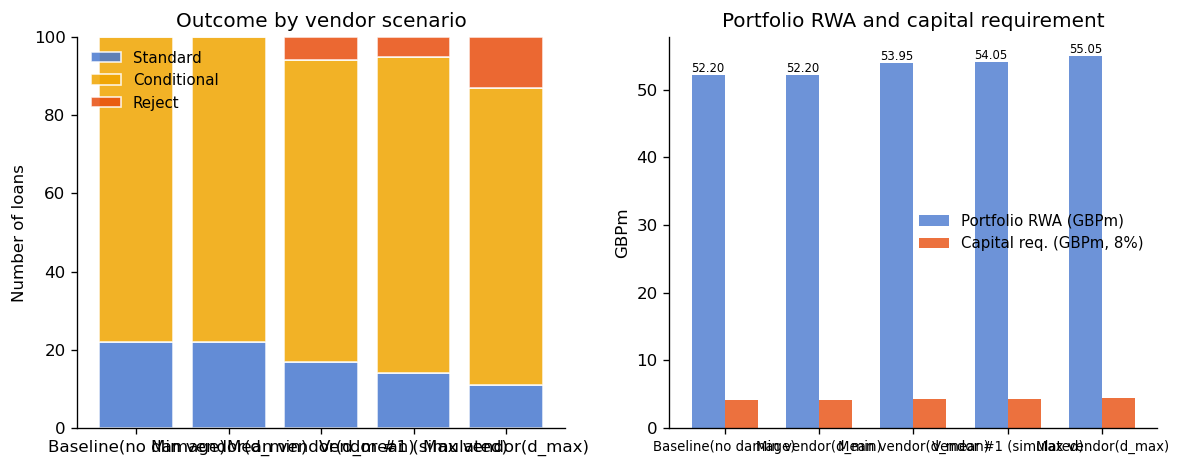

Portfolio RWA:
  Baseline(no damage)            GBP52.195m  (+0.0% vs baseline)
  Min vendor(d_min)              GBP52.195m  (+0.0% vs baseline)
  Mean vendor(d_mean)            GBP53.953m  (+3.4% vs baseline)
  Vendor #1 (simulated)          GBP54.053m  (+3.6% vs baseline)
  Max vendor(d_max)              GBP55.046m  (+5.5% vs baseline)


In [67]:
# Outcome distribution and RWA across vendor scenarios
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

scenarios    = ['Baseline(no damage)', 'Min vendor(d_min)', 'Mean vendor(d_mean)', f'Vendor #{VENDOR_SEED} (simulated)', 'Max vendor(d_max)']
all_outcomes = [outcome_base, out_min, out_mean, outcome, out_max]
all_rwa      = [rwa_base, rwa_min, rwa_mean, rwa, rwa_max]

# ── Left: stacked bar — outcome counts ───────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(scenarios))
for k, (name, col) in enumerate(zip(out_names, [BLUE, AMBER, RED])):
    vals = np.array([(o == k).sum() for o in all_outcomes], dtype=float)
    ax.bar(scenarios, vals, bottom=bottom, label=name, color=col, edgecolor='white', alpha=0.85)
    bottom += vals
ax.set_ylabel('Number of loans')
ax.set_title('Outcome by vendor scenario')
ax.legend(frameon=False, fontsize=9)

# ── Right: portfolio RWA and capital ─────────────────────────────────────────
ax = axes[1]
port_rwas    = [r.sum() for r in all_rwa]
port_capital = [CAPITAL_RATIO * r for r in port_rwas]
x = np.arange(len(scenarios))
w = 0.35
bars_rwa = ax.bar(x - w/2, port_rwas,    width=w, color=BLUE, alpha=0.8,
                  label='Portfolio RWA (GBPm)')
bars_cap = ax.bar(x + w/2, port_capital, width=w, color=RED,  alpha=0.8,
                  label=f'Capital req. (GBPm, {CAPITAL_RATIO*100:.0f}%)')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=8)
ax.set_ylabel('GBPm')
ax.set_title('Portfolio RWA and capital requirement')
ax.legend(frameon=False, fontsize=9)
for bar in bars_rwa:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print(f"Portfolio RWA:")
for sc, r in zip(scenarios, port_rwas):
    label = sc.replace('\n', ' ')
    print(f"  {label:30s} GBP{r:.3f}m  ({(r/port_rwas[0]-1)*100:+.1f}% vs baseline)")

In [68]:
# =============================================================================
# VENDOR UNCERTAINTY SWEEP  (N_VENDOR_DRAWS draws from triangular distributions)
# =============================================================================
_rng = np.random.default_rng(0)

# Vectorised triangular draws: shape (N_VENDOR_DRAWS, n)
u_mat  = _rng.uniform(size=(N_VENDOR_DRAWS, n))
span   = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc     = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
_left  = tri_a + np.sqrt(np.maximum(u_mat,       0) * span * np.maximum(tri_c - tri_a, 0))
_right = tri_b - np.sqrt(np.maximum(1.0 - u_mat, 0) * span * np.maximum(tri_b - tri_c, 0))
d_mat  = np.where(u_mat <= fc, _left, _right)
d_mat  = np.where(tri_b > tri_a, np.clip(d_mat, 0, 1), tri_a)

# Apply framing and transmission
d_eff_mat = d_mat * (AAL_FACTOR if FRAMING == 'aal' else 1.0)
v_imp_mat = np.maximum(v0[None, :] * (1.0 - THETA * d_eff_mat), v0[None, :] * 1e-6)
ltv_mat   = loan[None, :] / v_imp_mat
out_mat   = np.where(ltv_mat <= LTV_BAR_1, 0, np.where(ltv_mat <= LTV_BAR_2, 1, 2))
rw_mat    = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[out_mat]
rwa_mat   = loan[None, :] * rw_mat
cap_mat   = CAPITAL_RATIO * rwa_mat

# Portfolio-level aggregates: (N_VENDOR_DRAWS,)
port_rwa_draws = rwa_mat.sum(axis=1)
port_cap_draws = cap_mat.sum(axis=1)

# Outcome stability per loan
out_max_per_loan = out_mat.max(axis=0)
out_min_per_loan = out_mat.min(axis=0)
always_std = out_max_per_loan == 0
always_rej = out_min_per_loan == 2
unstable   = out_max_per_loan != out_min_per_loan

# Pairwise portfolio disagreement
ii, jj   = np.triu_indices(N_VENDOR_DRAWS, k=1)
rwa_diff = np.abs(port_rwa_draws[ii] - port_rwa_draws[jj])
cap_diff = np.abs(port_cap_draws[ii] - port_cap_draws[jj])

print(f"Framing: {framing_label}  |  theta={THETA}  |  N={N_VENDOR_DRAWS} vendor draws")
print(f"  Portfolio RWA: mean={port_rwa_draws.mean():.3f}m  "
      f"std={port_rwa_draws.std():.4f}m  "
      f"range=[{port_rwa_draws.min():.3f}, {port_rwa_draws.max():.3f}]m")
print(f"  Capital req.:  mean={port_cap_draws.mean():.4f}m  "
      f"std={port_cap_draws.std():.5f}m  "
      f"range=[{port_cap_draws.min():.4f}, {port_cap_draws.max():.4f}]m")
print(f"  Bucket instability: {unstable.sum()} loans flip outcome across vendor draws")

Framing: AAL (×0.25)  |  theta=0.5  |  N=1000 vendor draws
  Portfolio RWA: mean=53.687m  std=0.2484m  range=[52.788, 54.356]m
  Capital req.:  mean=4.2949m  std=0.01987m  range=[4.2230, 4.3484]m
  Bucket instability: 23 loans flip outcome across vendor draws


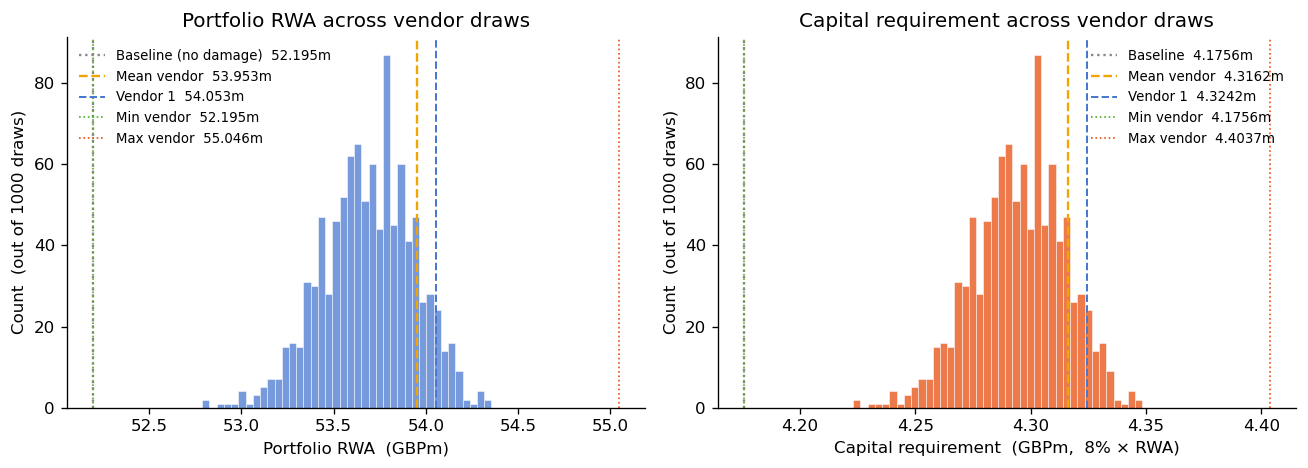

In [69]:
# Portfolio RWA and capital requirement distributions across vendor draws
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rwa_mean_pt = rwa_mean.sum()   # point estimate at mean damage

# ── Left: portfolio RWA ───────────────────────────────────────────────────────
ax = axes[0]
ax.hist(port_rwa_draws, bins=40, color=BLUE, alpha=0.75,
        edgecolor='white', linewidth=0.4)
ax.axvline(rwa_base.sum(),  color=GREY,  lw=1.4, ls=':',  label=f'Baseline (no damage)  {rwa_base.sum():.3f}m')
ax.axvline(rwa_mean.sum(),  color=AMBER, lw=1.4, ls='--', label=f'Mean vendor  {rwa_mean.sum():.3f}m')
ax.axvline(rwa.sum(),       color=BLUE,  lw=1.2, ls='--', label=f'Vendor {VENDOR_SEED}  {rwa.sum():.3f}m')
ax.axvline(rwa_min.sum(),   color=GREEN, lw=1.0, ls=':',  label=f'Min vendor  {rwa_min.sum():.3f}m')
ax.axvline(rwa_max.sum(),   color=RED,   lw=1.0, ls=':',  label=f'Max vendor  {rwa_max.sum():.3f}m')
ax.set_xlabel('Portfolio RWA  (GBPm)')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('Portfolio RWA across vendor draws')
ax.legend(frameon=False, fontsize=8)

# ── Right: capital requirement ────────────────────────────────────────────────
ax = axes[1]
ax.hist(port_cap_draws, bins=40, color=RED, alpha=0.75,
        edgecolor='white', linewidth=0.4)
ax.axvline(capital_base.sum(),              color=GREY,  lw=1.4, ls=':',
           label=f'Baseline  {capital_base.sum():.4f}m')
ax.axvline(CAPITAL_RATIO * rwa_mean.sum(), color=AMBER, lw=1.4, ls='--',
           label=f'Mean vendor  {CAPITAL_RATIO*rwa_mean.sum():.4f}m')
ax.axvline(capital.sum(),                  color=BLUE,  lw=1.2, ls='--',
           label=f'Vendor {VENDOR_SEED}  {capital.sum():.4f}m')
ax.axvline(CAPITAL_RATIO * rwa_min.sum(), color=GREEN, lw=1.0, ls=':',
           label=f'Min vendor  {CAPITAL_RATIO*rwa_min.sum():.4f}m')
ax.axvline(CAPITAL_RATIO * rwa_max.sum(), color=RED,   lw=1.0, ls=':',
           label=f'Max vendor  {CAPITAL_RATIO*rwa_max.sum():.4f}m')
ax.set_xlabel(f'Capital requirement  (GBPm,  {CAPITAL_RATIO*100:.0f}% × RWA)')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('Capital requirement across vendor draws')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

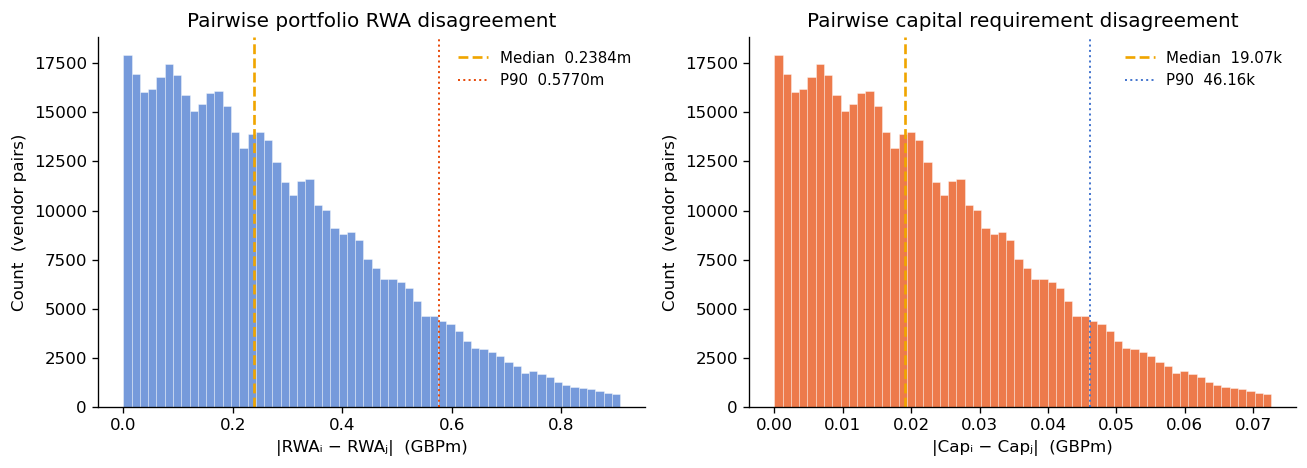

In [70]:
# Pairwise capital requirement disagreement between vendor pairs
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: pairwise |ΔRWA| ─────────────────────────────────────────────────────
ax = axes[0]
bins_rwa = np.linspace(0, np.percentile(rwa_diff, 99), 61)
ax.hist(rwa_diff, bins=bins_rwa, color=BLUE, alpha=0.75,
        edgecolor='white', linewidth=0.3)
ax.axvline(np.median(rwa_diff), color=AMBER, lw=1.6, ls='--',
           label=f'Median  {np.median(rwa_diff):.4f}m')
ax.axvline(np.percentile(rwa_diff, 90), color=RED, lw=1.2, ls=':',
           label=f'P90  {np.percentile(rwa_diff, 90):.4f}m')
ax.set_xlabel('|RWAᵢ − RWAⱼ|  (GBPm)')
ax.set_ylabel('Count  (vendor pairs)')
ax.set_title('Pairwise portfolio RWA disagreement')
ax.legend(frameon=False, fontsize=9)

# ── Right: pairwise |ΔCapital| ────────────────────────────────────────────────
ax = axes[1]
bins_cap = np.linspace(0, np.percentile(cap_diff, 99), 61)
ax.hist(cap_diff, bins=bins_cap, color=RED, alpha=0.75,
        edgecolor='white', linewidth=0.3)
ax.axvline(np.median(cap_diff), color=AMBER, lw=1.6, ls='--',
           label=f'Median  {np.median(cap_diff)*1e3:.2f}k')
ax.axvline(np.percentile(cap_diff, 90), color=BLUE, lw=1.2, ls=':',
           label=f'P90  {np.percentile(cap_diff, 90)*1e3:.2f}k')
ax.set_xlabel(f'|Capᵢ − Capⱼ|  (GBPm)')
ax.set_ylabel('Count  (vendor pairs)')
ax.set_title('Pairwise capital requirement disagreement')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

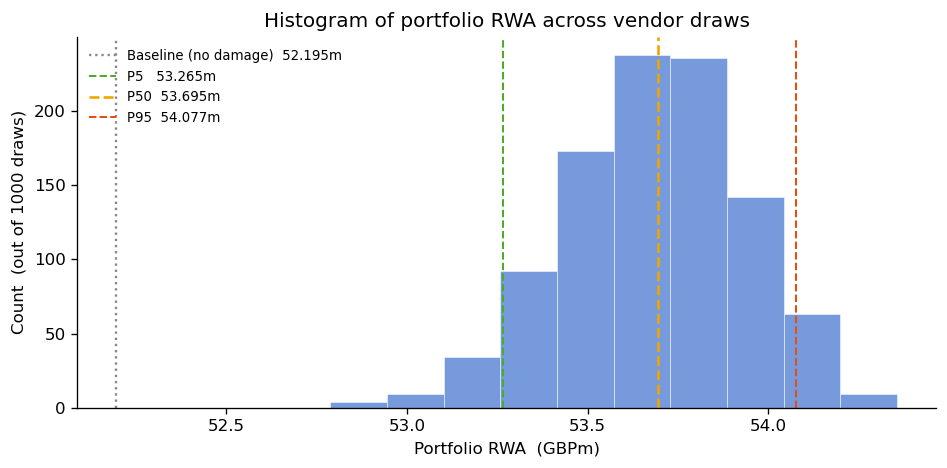

In [71]:
# Figure: Histogram of portfolio RWA across vendor draws
fig, ax = plt.subplots(figsize=(8, 4))

p5  = np.percentile(port_rwa_draws, 5)
p50 = np.percentile(port_rwa_draws, 50)
p95 = np.percentile(port_rwa_draws, 95)

ax.hist(port_rwa_draws, bins=10, color=BLUE, alpha=0.75,
        edgecolor='white', linewidth=0.4)
ax.axvline(rwa_base.sum(), color=GREY,  lw=1.4, ls=':',
           label=f'Baseline (no damage)  {rwa_base.sum():.3f}m')
ax.axvline(p5,  color=GREEN, lw=1.2, ls='--',
           label=f'P5   {p5:.3f}m')
ax.axvline(p50, color=AMBER, lw=1.6, ls='--',
           label=f'P50  {p50:.3f}m')
ax.axvline(p95, color=RED,   lw=1.2, ls='--',
           label=f'P95  {p95:.3f}m')
ax.set_xlabel('Portfolio RWA  (GBPm)')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('Histogram of portfolio RWA across vendor draws')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


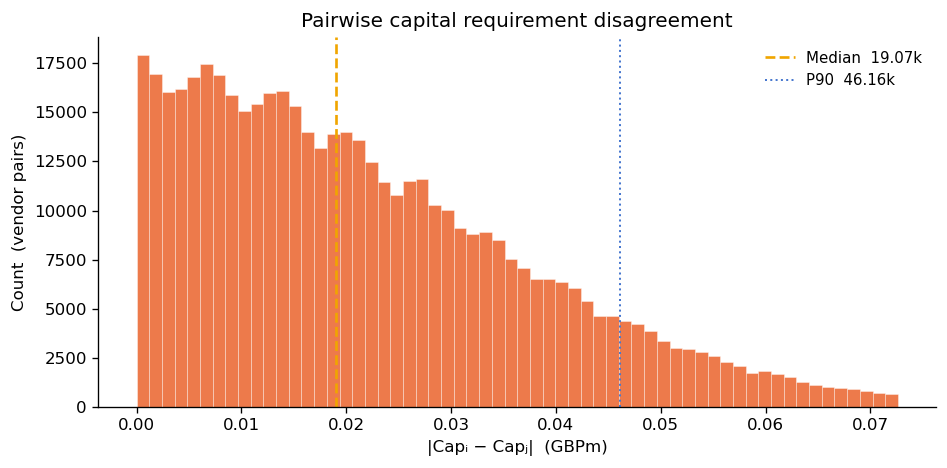

In [72]:
# Figure: Pairwise capital requirement disagreement across vendor draws
fig, ax = plt.subplots(figsize=(8, 4))

bins_cap = np.linspace(0, np.percentile(cap_diff, 99), 61)
ax.hist(cap_diff, bins=bins_cap, color=RED, alpha=0.75,
        edgecolor='white', linewidth=0.3)
ax.axvline(np.median(cap_diff), color=AMBER, lw=1.6, ls='--',
           label=f'Median  {np.median(cap_diff)*1e3:.2f}k')
ax.axvline(np.percentile(cap_diff, 90), color=BLUE, lw=1.2, ls=':',
           label=f'P90  {np.percentile(cap_diff, 90)*1e3:.2f}k')
ax.set_xlabel(f'|Capᵢ − Capⱼ|  (GBPm)')
ax.set_ylabel('Count  (vendor pairs)')
ax.set_title('Pairwise capital requirement disagreement')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


In [54]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
ead_total = loan.sum()
col = 'Result'

stats_dict = {
    # ── Single vendor draw ───────────────────────────────────────────────────
    'Standard loans':                          int((outcome == 0).sum()),
    'Conditional loans':                       int((outcome == 1).sum()),
    'Reject loans':                            int((outcome == 2).sum()),
    'Portfolio RWA — single draw (GBPm)':      round(rwa.sum(), 3),
    'Capital req. — single draw (GBPm)':       round(capital.sum(), 4),
    'RWA density (% of loan book)':            round(rwa.sum() / ead_total * 100, 2),
    # ── Vendor uncertainty (N draws) ────────────────────────────────────────
    'RWA mean across vendors (GBPm)':          round(float(port_rwa_draws.mean()), 3),
    'RWA std across vendors (GBPm)':           round(float(port_rwa_draws.std()), 4),
    'RWA CV':                                  round(float(port_rwa_draws.std() / port_rwa_draws.mean()), 4),
    'RWA P10 (GBPm)':                          round(float(np.percentile(port_rwa_draws, 10)), 3),
    'RWA P50 / median (GBPm)':                 round(float(np.percentile(port_rwa_draws, 50)), 3),
    'RWA P90 (GBPm)':                          round(float(np.percentile(port_rwa_draws, 90)), 3),
    'RWA range (P90 − P10, GBPm)':        round(float(np.percentile(port_rwa_draws, 90) - np.percentile(port_rwa_draws, 10)), 4),
    'Capital mean (GBPm)':                     round(float(port_cap_draws.mean()), 4),
    'Capital P10 (GBPm)':                      round(float(np.percentile(port_cap_draws, 10)), 4),
    'Capital P50 (GBPm)':                      round(float(np.percentile(port_cap_draws, 50)), 4),
    'Capital P90 (GBPm)':                      round(float(np.percentile(port_cap_draws, 90)), 4),
    'Capital range (P90 − P10, GBPm)':    round(float(np.percentile(port_cap_draws, 90) - np.percentile(port_cap_draws, 10)), 5),
    # ── Outcome stability ────────────────────────────────────────────────────
    'Always Standard (n loans)':               int(always_std.sum()),
    'Outcome unstable — flip bucket (n)':      int(unstable.sum()),
    'Always Reject (n loans)':                 int(always_rej.sum()),
    'Bucket instability rate':                 round(float(unstable.mean()), 4),
    # ── Pairwise vendor comparison ───────────────────────────────────────────
    'Pairwise |ΔRWA| median (GBPm)':      round(float(np.median(rwa_diff)), 4),
    'Pairwise |ΔRWA| P90 (GBPm)':         round(float(np.percentile(rwa_diff, 90)), 4),
    'Pairwise |ΔCap| median (GBPk)':       round(float(np.median(cap_diff)) * 1e3, 3),
    'Pairwise |ΔCap| P90 (GBPk)':          round(float(np.percentile(cap_diff, 90)) * 1e3, 3),
    'Pairwise |ΔCap| median (% mean cap)': round(float(np.median(cap_diff)) / port_cap_draws.mean() * 100, 3),
}

df_stats = pd.DataFrame({col: stats_dict})

sections = [
    ('Single vendor draw', [
        'Standard loans', 'Conditional loans', 'Reject loans',
        'Portfolio RWA — single draw (GBPm)', 'Capital req. — single draw (GBPm)',
        'RWA density (% of loan book)',
    ]),
    (f'Vendor uncertainty  (N = {N_VENDOR_DRAWS} draws)', [
        'RWA mean across vendors (GBPm)', 'RWA std across vendors (GBPm)', 'RWA CV',
        'RWA P10 (GBPm)', 'RWA P50 / median (GBPm)', 'RWA P90 (GBPm)',
        'RWA range (P90 − P10, GBPm)',
        'Capital mean (GBPm)', 'Capital P10 (GBPm)', 'Capital P50 (GBPm)',
        'Capital P90 (GBPm)', 'Capital range (P90 − P10, GBPm)',
    ]),
    ('Outcome stability', [
        'Always Standard (n loans)', 'Outcome unstable — flip bucket (n)',
        'Always Reject (n loans)', 'Bucket instability rate',
    ]),
    ('Pairwise vendor comparison', [
        'Pairwise |ΔRWA| median (GBPm)', 'Pairwise |ΔRWA| P90 (GBPm)',
        'Pairwise |ΔCap| median (GBPk)', 'Pairwise |ΔCap| P90 (GBPk)',
        'Pairwise |ΔCap| median (% mean cap)',
    ]),
]

print(f'Framing: {framing_label}  |  theta={THETA}  |  N={N_VENDOR_DRAWS}  |  Vendor seed={VENDOR_SEED}')
print(f'Total loan book: GBP{ead_total:.2f}m\n')

_style = [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '1em')]}]
for section_name, keys in sections:
    # Use only keys that exist in the index (handles the em-dash variants)
    valid_keys = [k for k in keys if k in df_stats.index]
    display(df_stats.loc[valid_keys].style
            .format(lambda v: f'{v:.4g}' if isinstance(v, float) else str(v), subset=[col])
            .set_caption(section_name)
            .set_table_styles(_style))

Framing: AAL (×0.25)  |  theta=0.5  |  N=1000  |  Vendor seed=1
Total loan book: GBP60.45m



,Result
Standard loans,14
Conditional loans,81
Reject loans,5
Portfolio RWA — single draw (GBPm),54.05
Capital req. — single draw (GBPm),4.324
RWA density (% of loan book),89.42


,Result
RWA mean across vendors (GBPm),53.69
RWA std across vendors (GBPm),0.2484
RWA CV,0.0046
RWA P10 (GBPm),53.37
RWA P50 / median (GBPm),53.7
RWA P90 (GBPm),54
"RWA range (P90 − P10, GBPm)",0.6276
Capital mean (GBPm),4.295
Capital P10 (GBPm),4.27
Capital P50 (GBPm),4.296


,Result
Always Standard (n loans),11
Outcome unstable — flip bucket (n),23
Always Reject (n loans),0
Bucket instability rate,0.23


,Result
Pairwise |ΔRWA| median (GBPm),0.2384
Pairwise |ΔRWA| P90 (GBPm),0.577
Pairwise |ΔCap| median (GBPk),19.07
Pairwise |ΔCap| P90 (GBPk),46.16
Pairwise |ΔCap| median (% mean cap),0.444


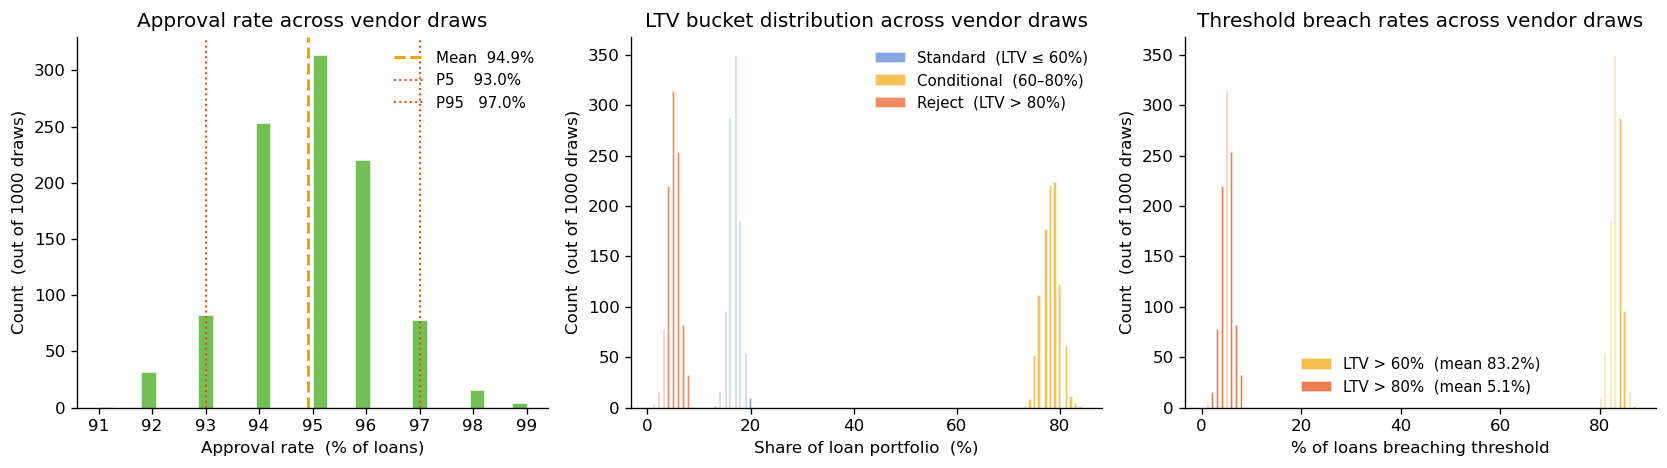


Approval rate:  mean=94.9%  std=1.27%  [P5=93.0%, P95=97.0%]
Standard  bucket:     mean=16.8%  range=[13.0%, 20.0%]
Conditional bucket:   mean=78.1%  range=[73.0%, 84.0%]
Reject bucket:        mean=5.1%  range=[1.0%, 9.0%]
Breach LTV>60%:  mean=83.2%  range=[80.0%, 87.0%]
Breach LTV>80%:  mean=5.1%  range=[1.0%, 9.0%]


In [55]:
# =============================================================================
# APPROVAL RATE, LTV BUCKET DISTRIBUTION, AND THRESHOLD BREACHES
# Across N_VENDOR_DRAWS vendor draws using out_mat computed in the sweep above.
# =============================================================================

# Per-draw fractions (shape: N_VENDOR_DRAWS)
frac_standard    = (out_mat == 0).mean(axis=1)   # % standard
frac_conditional = (out_mat == 1).mean(axis=1)   # % conditional
frac_reject      = (out_mat == 2).mean(axis=1)   # % rejected
approval_rate    = 1.0 - frac_reject             # standard + conditional

# % of loans with stressed LTV breaching each threshold
breach_bar1 = (ltv_mat > LTV_BAR_1).mean(axis=1)  # LTV > 60% (enters conditional or reject zone)
breach_bar2 = (ltv_mat > LTV_BAR_2).mean(axis=1)  # LTV > 80% (reject zone)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Left: Approval rate distribution ─────────────────────────────────────────
ax = axes[0]
ax.hist(approval_rate * 100, bins=30, color=GREEN, alpha=0.78,
        edgecolor='white', linewidth=0.4)
ax.axvline(approval_rate.mean() * 100, color=AMBER, lw=1.8, ls='--',
           label=f'Mean  {approval_rate.mean()*100:.1f}%')
ax.axvline(np.percentile(approval_rate, 5) * 100, color=RED, lw=1.2, ls=':',
           label=f'P5    {np.percentile(approval_rate, 5)*100:.1f}%')
ax.axvline(np.percentile(approval_rate, 95) * 100, color=RED, lw=1.2, ls=':',
           label=f'P95   {np.percentile(approval_rate, 95)*100:.1f}%')
ax.set_xlabel('Approval rate  (% of loans)')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('Approval rate across vendor draws')
ax.legend(frameon=False, fontsize=9)

# ── Middle: LTV bucket composition across vendor draws ───────────────────────
ax = axes[1]
ax.hist(frac_standard    * 100, bins=25, color=BLUE,  alpha=0.65,
        edgecolor='white', linewidth=0.3, label='Standard  (LTV ≤ 60%)')
ax.hist(frac_conditional * 100, bins=25, color=AMBER, alpha=0.65,
        edgecolor='white', linewidth=0.3, label='Conditional  (60–80%)')
ax.hist(frac_reject      * 100, bins=25, color=RED,   alpha=0.65,
        edgecolor='white', linewidth=0.3, label='Reject  (LTV > 80%)')
ax.set_xlabel('Share of loan portfolio  (%)')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('LTV bucket distribution across vendor draws')
ax.legend(frameon=False, fontsize=9)

# ── Right: % breaching LTV thresholds ────────────────────────────────────────
ax = axes[2]
ax.hist(breach_bar1 * 100, bins=25, color=AMBER, alpha=0.72,
        edgecolor='white', linewidth=0.3,
        label=f'LTV > {LTV_BAR_1:.0%}  (mean {breach_bar1.mean()*100:.1f}%)')
ax.hist(breach_bar2 * 100, bins=25, color=RED,   alpha=0.72,
        edgecolor='white', linewidth=0.3,
        label=f'LTV > {LTV_BAR_2:.0%}  (mean {breach_bar2.mean()*100:.1f}%)')
ax.set_xlabel('% of loans breaching threshold')
ax.set_ylabel(f'Count  (out of {N_VENDOR_DRAWS} draws)')
ax.set_title('Threshold breach rates across vendor draws')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nApproval rate:  mean={approval_rate.mean()*100:.1f}%  "
      f"std={approval_rate.std()*100:.2f}%  "
      f"[P5={np.percentile(approval_rate,5)*100:.1f}%, P95={np.percentile(approval_rate,95)*100:.1f}%]")
print(f"Standard  bucket:     mean={frac_standard.mean()*100:.1f}%  "
      f"range=[{frac_standard.min()*100:.1f}%, {frac_standard.max()*100:.1f}%]")
print(f"Conditional bucket:   mean={frac_conditional.mean()*100:.1f}%  "
      f"range=[{frac_conditional.min()*100:.1f}%, {frac_conditional.max()*100:.1f}%]")
print(f"Reject bucket:        mean={frac_reject.mean()*100:.1f}%  "
      f"range=[{frac_reject.min()*100:.1f}%, {frac_reject.max()*100:.1f}%]")
print(f"Breach LTV>{LTV_BAR_1:.0%}:  mean={breach_bar1.mean()*100:.1f}%  "
      f"range=[{breach_bar1.min()*100:.1f}%, {breach_bar1.max()*100:.1f}%]")
print(f"Breach LTV>{LTV_BAR_2:.0%}:  mean={breach_bar2.mean()*100:.1f}%  "
      f"range=[{breach_bar2.min()*100:.1f}%, {breach_bar2.max()*100:.1f}%]")

Loan-level classification stability across 1000 vendor draws:
  Always standard       :  11 loans  (11%)
  Always conditional    :  66 loans  (66%)
  Always reject         :   0 loans  (0%)
  Contested (>=2 classes):  23 loans  (23%)


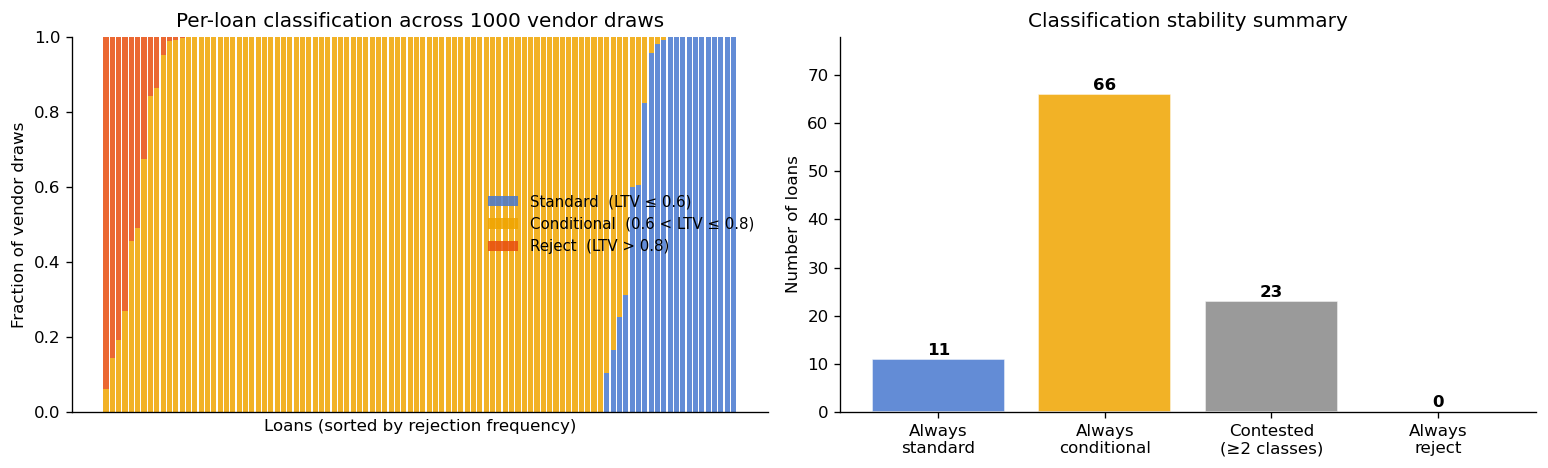

In [56]:
# =============================================================================
# LOAN-LEVEL CLASSIFICATION DISAGREEMENT ACROSS VENDOR DRAWS
# =============================================================================

# Per-loan fractions across all N_VENDOR_DRAWS vendor draws
frac_std_loan  = (out_mat == 0).mean(axis=0)   # shape (n,)
frac_cond_loan = (out_mat == 1).mean(axis=0)
frac_rej_loan  = (out_mat == 2).mean(axis=0)

# Stability summary counts
n_always_std  = int(always_std.sum())
n_always_rej  = int(always_rej.sum())
n_contested   = int(unstable.sum())
n_always_cond = n - n_always_std - n_always_rej - n_contested

print(f"Loan-level classification stability across {N_VENDOR_DRAWS} vendor draws:")
print(f"  Always standard       : {n_always_std:3d} loans  ({n_always_std/n*100:.0f}%)")
print(f"  Always conditional    : {n_always_cond:3d} loans  ({n_always_cond/n*100:.0f}%)")
print(f"  Always reject         : {n_always_rej:3d} loans  ({n_always_rej/n*100:.0f}%)")
print(f"  Contested (>=2 classes): {n_contested:3d} loans  ({n_contested/n*100:.0f}%)")

# Sort loans by rejection frequency (desc), then conditional frequency (desc)
sort_idx = np.argsort(-frac_rej_loan - 0.5 * frac_cond_loan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: per-loan stacked bar of classification fractions ───────────────────
ax = axes[0]
x  = np.arange(n)
b1 = frac_std_loan[sort_idx]
b2 = frac_cond_loan[sort_idx]
b3 = frac_rej_loan[sort_idx]
ax.bar(x, b1,        color=BLUE,  alpha=0.85, label=f'Standard  (LTV ≤ {LTV_BAR_1})')
ax.bar(x, b2, bottom=b1,          color=AMBER, alpha=0.85, label=f'Conditional  ({LTV_BAR_1} < LTV ≤ {LTV_BAR_2})')
ax.bar(x, b3, bottom=b1 + b2,     color=RED,   alpha=0.85, label=f'Reject  (LTV > {LTV_BAR_2})')
ax.set_xlabel('Loans (sorted by rejection frequency)')
ax.set_ylabel('Fraction of vendor draws')
ax.set_title(f'Per-loan classification across {N_VENDOR_DRAWS} vendor draws')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)

# ── Right: stability summary bar chart ───────────────────────────────────────
ax = axes[1]
categories = ['Always\nstandard', 'Always\nconditional', 'Contested\n(≥2 classes)', 'Always\nreject']
counts     = [n_always_std, n_always_cond, n_contested, n_always_rej]
colours    = [BLUE, AMBER, GREY, RED]
bars = ax.bar(categories, counts, color=colours, alpha=0.85, edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of loans')
ax.set_title('Classification stability summary')
ax.set_ylim(0, max(counts) * 1.18)

plt.tight_layout()
plt.show()